# Laboratorio 8

----

Brandon Reyes

Santiago Pereira

Nancy Mazariegos

Utilice PyTorch o TensorFlow/Keras a su elección. No se proporciona código base; usted debe construir su solución apoyándose en la documentación oficial, recursos académicos y su criterio de ingeniería. Ejecute sus experimentos en Google Colab, Kaggle Notebooks o GPU local. Entregue el enlace al notebook con todas las celdas ejecutadas y los resultados visibles. El notebook debe estar limpio, comentado y reproducible. La evaluación considera no solo que el código funcione, sino que usted entienda cada decisión que tomó y la justifique en su reporte.

1.. Preparación del Dataset:

a. Dataset: Descargue un subconjunto del dataset SKU110K (mínimo 500 imágenes de
entrenamiento, 100 de validación, 100 de prueba). Si el dataset completo no es accesible,
puede utilizar Grocery Store Dataset o Open Images V7 filtrado por categorías de productos
de anaquel. Documente en su reporte la fuente exacta y el proceso de descarga.

b. Preprocesamiento: Asegúrese de que las anotaciones estén en formato compatible con el
detector elegido (COCO JSON, YOLO .txt, o Pascal VOC XML). Justifique en su reporte cualquier
conversión que realice y documente la distribución de clases del subconjunto utilizado.

c. Verificación: Visualice al menos 5 imágenes con sus bounding boxes anotados antes del
entrenamiento. Incluya esas visualizaciones en su notebook

In [5]:
import os
import shutil

DATASET_ORIG = "./GroceryStoreDataset-master/dataset"
OUTPUT_DIR = "./dataset_shelves"

splits = ["train", "val", "test"]

for split in splits:
    os.makedirs(f"{OUTPUT_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/labels/{split}", exist_ok=True)

def create_bbox():
    return "0 0.5 0.5 0.8 0.8"

for split in splits:
    txt_file = f"{DATASET_ORIG}/{split}.txt"

    with open(txt_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split(",")
        img_rel_path = parts[0]

        img_src = f"{DATASET_ORIG}/{img_rel_path}"
        img_name = os.path.basename(img_rel_path)

        img_dst = f"{OUTPUT_DIR}/images/{split}/{img_name}"
        label_dst = f"{OUTPUT_DIR}/labels/{split}/{img_name.replace('.jpg','.txt')}"

        if os.path.exists(img_src):
            shutil.copy(img_src, img_dst)

            with open(label_dst, "w") as lf:
                lf.write(create_bbox())

print("Dataset convertido correctamente")

Dataset convertido correctamente


In [6]:
DATASET_ROOT = "./dataset_shelves"

In [7]:
from pathlib import Path

DATASET_ROOT = "./dataset_shelves"

def count_files(folder, exts=None):
    folder = Path(folder)
    if not folder.exists():
        return 0
    if exts is None:
        return len(list(folder.glob("*")))
    return len([p for p in folder.glob("*") if p.suffix.lower() in exts])

img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "val", "test"]:
    n_imgs = count_files(f"{DATASET_ROOT}/images/{split}", img_exts)
    n_lbls = count_files(f"{DATASET_ROOT}/labels/{split}", {".txt"})
    print(f"{split}: imágenes={n_imgs}, labels={n_lbls}")

train: imágenes=2640, labels=2640
val: imágenes=296, labels=296
test: imágenes=2485, labels=2485


In [8]:
train_count = count_files(f"{DATASET_ROOT}/images/train", img_exts)
val_count   = count_files(f"{DATASET_ROOT}/images/val", img_exts)
test_count  = count_files(f"{DATASET_ROOT}/images/test", img_exts)

print("Train:", train_count)
print("Val:  ", val_count)
print("Test: ", test_count)

if train_count < 500 or val_count < 100 or test_count < 100:
    print("Advertencia: no cumple el mínimo del enunciado.")
else:
    print("El subconjunto cumple con el mínimo solicitado.")

Train: 2640
Val:   296
Test:  2485
El subconjunto cumple con el mínimo solicitado.


In [9]:
import yaml
import os

data_yaml = {
    "path": os.path.abspath(DATASET_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "product"
    }
}

with open(f"{DATASET_ROOT}/data.yaml", "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("data.yaml creado en:", f"{DATASET_ROOT}/data.yaml")

data.yaml creado en: ./dataset_shelves/data.yaml


In [10]:
def validate_yolo_labels(labels_dir, num_classes=1):
    errors = []
    label_files = list(Path(labels_dir).glob("*.txt"))

    for lf in label_files:
        with open(lf, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        for i, line in enumerate(lines, start=1):
            parts = line.split()
            if len(parts) != 5:
                errors.append((lf.name, i, "No tiene 5 valores"))
                continue

            try:
                cls = int(parts[0])
                vals = list(map(float, parts[1:]))

                if not (0 <= cls < num_classes):
                    errors.append((lf.name, i, "class_id fuera de rango"))

                for v in vals:
                    if not (0 <= v <= 1):
                        errors.append((lf.name, i, "coordenada fuera de [0,1]"))
            except:
                errors.append((lf.name, i, "No se pudo parsear"))
    
    print(f"Revisados: {len(label_files)} archivos")
    print(f"Errores: {len(errors)}")
    if errors[:10]:
        print("Primeros errores:")
        for e in errors[:10]:
            print(e)

validate_yolo_labels(f"{DATASET_ROOT}/labels/train", num_classes=1)
validate_yolo_labels(f"{DATASET_ROOT}/labels/val", num_classes=1)
validate_yolo_labels(f"{DATASET_ROOT}/labels/test", num_classes=1)

Revisados: 2640 archivos
Errores: 0
Revisados: 296 archivos
Errores: 0
Revisados: 2485 archivos
Errores: 0


In [11]:
import pandas as pd
from collections import Counter

def class_distribution(labels_dir, class_names):
    counts = Counter()
    label_files = list(Path(labels_dir).glob("*.txt"))

    for lf in label_files:
        with open(lf, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
        for line in lines:
            cls = int(line.split()[0])
            counts[cls] += 1

    rows = []
    for i, name in enumerate(class_names):
        rows.append({
            "class_id": i,
            "class_name": name,
            "instances": counts[i]
        })
    return pd.DataFrame(rows)

class_names = ["product"]

dist_train = class_distribution(f"{DATASET_ROOT}/labels/train", class_names)
dist_val   = class_distribution(f"{DATASET_ROOT}/labels/val", class_names)
dist_test  = class_distribution(f"{DATASET_ROOT}/labels/test", class_names)

print("Train")
display(dist_train)

print("Val")
display(dist_val)

print("Test")
display(dist_test)

Train


,class_id,class_name,instances
0,0,product,2640


Val


,class_id,class_name,instances
0,0,product,296


Test


,class_id,class_name,instances
0,0,product,2485


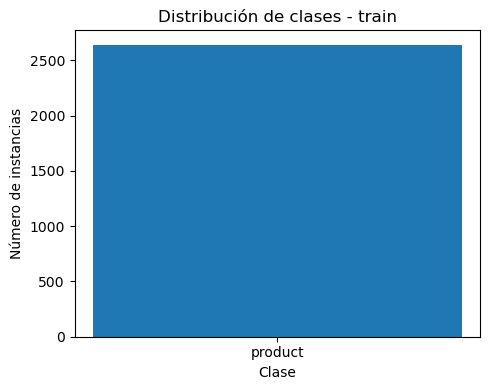

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.bar(dist_train["class_name"], dist_train["instances"])
plt.title("Distribución de clases - train")
plt.xlabel("Clase")
plt.ylabel("Número de instancias")
plt.tight_layout()
plt.show()

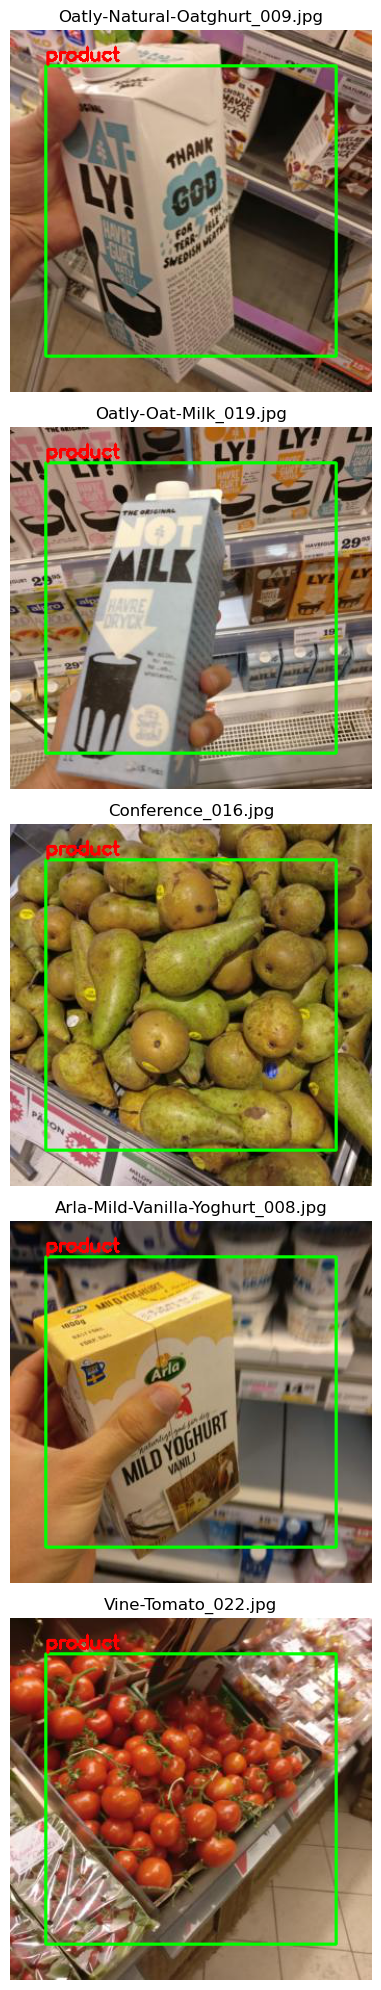

In [13]:
import cv2
import random
import matplotlib.pyplot as plt

def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = int((xc - w / 2) * img_w)
    y1 = int((yc - h / 2) * img_h)
    x2 = int((xc + w / 2) * img_w)
    y2 = int((yc + h / 2) * img_h)
    return x1, y1, x2, y2

def draw_boxes(image_path, label_path, class_names):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    if Path(label_path).exists():
        with open(label_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        for line in lines:
            cls, xc, yc, bw, bh = line.split()
            cls = int(cls)
            xc, yc, bw, bh = map(float, [xc, yc, bw, bh])

            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, w, h)

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                image,
                class_names[cls],
                (x1, max(20, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )
    return image

train_images = list(Path(f"{DATASET_ROOT}/images/train").glob("*"))
sample_images = random.sample(train_images, min(5, len(train_images)))

fig, axes = plt.subplots(len(sample_images), 1, figsize=(10, 4 * len(sample_images)))
if len(sample_images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_images):
    label_path = Path(f"{DATASET_ROOT}/labels/train/{img_path.stem}.txt")
    drawn = draw_boxes(img_path, label_path, class_names)
    ax.imshow(drawn)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()